In [1]:
# 1. The seventh pandemic genomic islands were identified through BLAST (alignment with N16961) (Baddam et al., 2020)
# 2. First part of the script includes the classification of the hits (VSPI and VSPII)
# 3. The logic used for thr classification has been commented along with the codes
# 4. For each VSP genomic island classification, iTOL input file has been generated. (the color codes might be changed during visualisation)
# 5. In the second part PCoA with only accessory genes has been carried out
# 6. After ML the predicted serotypes were visualised on the PCoA plots

In [1]:
import glob
import pandas as pd
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skbio.stats.ordination import pcoa
from skbio import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


from skbio.stats.distance import permanova, permdisp

from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg
import textwrap


# Seventh pandemic genomic islands

## vsp-I

### combining all hits

In [12]:
all_rows = []
all_samples = []

for f in glob.glob("/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspI/vspI_hits/*.tsv"):   
    base = os.path.basename(f)   # blast hit file names(.tsv) [format eg: VC_0001_vspI_hits.tsv]
    sample_id = base.replace("_vspI_hits.tsv", "")   # Sample_IDs
    all_samples.append(sample_id) 

    if os.stat(f).st_size == 0:    # handling empty blast tsv files 
        continue

    else:
        df = pd.read_csv(f, sep="\t", header=None)

        df.columns = ["qseqid","contig","pident","aln_len","mismatch","gapopen",
                      "qstart","qend","sstart","send","evalue","bitscore"]    # columns

        df.insert(0, "Sample_ID", sample_id)    # adding sample_ids

        df = df[["Sample_ID","contig","qstart","qend","sstart","send",
                 "pident","aln_len","evalue","bitscore"]] 

    all_rows.append(df)

vspI_hits = pd.concat(all_rows, ignore_index=True)

vspI_hits


# checked - contigs and genome ids along with the blast hits in a df

,Sample_ID,contig,qstart,qend,sstart,send,pident,aln_len,evalue,bitscore
0,VC_0005,NZ_JMBN01000020.1,1,14026,19111,33135,99.986,14026,0.0,25889.0
1,VC_0007,NZ_JIDH01000066.1,1,14026,86949,72924,100.000,14026,0.0,25902.0
2,VC_0014,NZ_CP007634.1,1,14026,2601289,2615314,99.993,14026,0.0,25896.0
3,VC_0015,NZ_JSCC01000020.1,1,14026,19267,33292,99.993,14026,0.0,25896.0
4,VC_0017,NZ_JSSV01000021.1,1,14026,19251,33276,99.993,14026,0.0,25896.0
...,...,...,...,...,...,...,...,...,...,...
1188,VC_1862,NZ_SIUT01000082.1,1,2096,83,2178,100.000,2096,0.0,3871.0
1189,VC_1863,NZ_SIUS01000036.1,1,12049,12176,128,99.992,12049,0.0,22245.0
1190,VC_1863,NZ_SIUS01000031.1,12043,14026,46165,44182,100.000,1984,0.0,3664.0
1191,VC_1864,NZ_SIUR01000044.1,1,12049,83,12131,99.992,12049,0.0,22245.0


### blast hits filtering

In [13]:
vspI_hits[["pident",'evalue','bitscore','aln_len']].describe()

,pident,evalue,bitscore,aln_len
count,1193.000000,1.193000e+03,1193.000000,1193.000000
mean,98.895474,9.892588e-09,19371.390025,10590.801341
std,3.749148,1.391804e-07,10021.165852,5305.672030
min,79.606000,0.000000e+00,54.700000,29.000000
25%,99.992000,0.000000e+00,9254.000000,5480.000000
50%,99.993000,0.000000e+00,25896.000000,14026.000000
75%,99.993000,0.000000e+00,25896.000000,14026.000000
max,100.000000,1.980000e-06,25902.000000,14038.000000


In [14]:
# total length of vspI is around 14kb
vspI_hits = vspI_hits[(vspI_hits["evalue"] <= 1e-5) &( vspI_hits["pident"] >= 90) & (vspI_hits["aln_len"] >= 500)]
# filtering for high confidence VSP-I hits and removing short/spurious alignments

In [15]:
vspI_hits[["pident",'evalue','bitscore','aln_len']].describe()

,pident,evalue,bitscore,aln_len
count,1020.000000,1020.0,1020.000000,1020.000000
mean,99.849034,0.0,22403.339216,12155.856863
std,0.950633,0.0,7314.773462,3926.788018
min,90.987000,0.0,1303.000000,705.000000
25%,99.992000,0.0,23756.500000,12870.250000
50%,99.993000,0.0,25896.000000,14026.000000
75%,99.993000,0.0,25896.000000,14026.000000
max,100.000000,0.0,25902.000000,14038.000000


### handling hits from different contigs and computing coverage

In [16]:
dup_samples = vspI_hits["Sample_ID"].value_counts()   
dup_samples = dup_samples[dup_samples > 1]  # genomnes with multiple hits
duplicates_df = vspI_hits[vspI_hits["Sample_ID"].isin(dup_samples.index)]  
duplicates_df.head(15)  # table with more than one hit per genome

,Sample_ID,contig,qstart,qend,sstart,send,pident,aln_len,evalue,bitscore
57,VC_0070,NZ_CWSJ01000017.1,1,14026,19249,33274,100.000,14026,0.0,25902.0
58,VC_0070,NZ_CWSJ01000011.1,1,14026,93962,79937,100.000,14026,0.0,25902.0
74,VC_0085,NZ_CWNL01000011.1,5191,14026,142010,133175,100.000,8836,0.0,16318.0
75,VC_0085,NZ_CWNL01000013.1,1,5193,5244,52,100.000,5193,0.0,9590.0
81,VC_0091,NZ_CWOT01000020.1,1,10471,57618,47148,99.990,10471,0.0,19331.0
82,VC_0091,NZ_CWOT01000020.1,10994,14026,46554,43522,99.967,3033,0.0,5596.0
105,VC_0135,NZ_LOSL02000001.1,3994,9535,1630564,1625023,96.807,5543,0.0,9254.0
106,VC_0135,NZ_LOSL02000001.1,11236,14026,1623837,1621047,91.365,2791,0.0,3819.0
232,VC_0315,NZ_NTBP01000025.1,1,12049,19255,31303,99.992,12049,0.0,22245.0
233,VC_0315,NZ_NTBP01000010.1,12043,14026,77,2060,100.000,1984,0.0,3664.0


#### testing for different cases

In [17]:
"""
print('cases with overlaps')
one = vspI_hits[vspI_hits["Sample_ID"] == "VC_0091"]
intervals = list(zip(one["qstart"], one["qend"]))
print("Original:", intervals)
intervals = sorted(intervals)
print("Sorted:", intervals)

merged = []
for start, end in intervals: 
    print("Processing:", (start, end))
    if not merged:
        merged.append([start, end])
        print("added:", merged)  # appending the coordinates
    elif start > merged[-1][1]:
        print("No overlap")   # if the start position is greater that the previous contig's coordinates - no overlaps
        merged.append([start, end])  # apending it separately
        print("Merged:", merged)    
    else:
        print("Overlap detected")
        print("Before:", merged[-1])
        merged[-1][1] = max(merged[-1][1], end)   # max of qend coordinates
        print("After:", merged[-1])
        print(merged)

total = sum(e - s + 1 for s, e in merged) 
print(merged, total)
"""

'\nprint(\'cases with overlaps\')\none = vspI_hits[vspI_hits["Sample_ID"] == "VC_0091"]\nintervals = list(zip(one["qstart"], one["qend"]))\nprint("Original:", intervals)\nintervals = sorted(intervals)\nprint("Sorted:", intervals)\n\nmerged = []\nfor start, end in intervals: \n    print("Processing:", (start, end))\n    if not merged:\n        merged.append([start, end])\n        print("added:", merged)  # appending the coordinates\n    elif start > merged[-1][1]:\n        print("No overlap")   # if the start position is greater that the previous contig\'s coordinates - no overlaps\n        merged.append([start, end])  # apending it separately\n        print("Merged:", merged)    \n    else:\n        print("Overlap detected")\n        print("Before:", merged[-1])\n        merged[-1][1] = max(merged[-1][1], end)   # max of qend coordinates\n        print("After:", merged[-1])\n        print(merged)\n\ntotal = sum(e - s + 1 for s, e in merged) \nprint(merged, total)\n'

In [18]:
"""
print('cases without overlaps')
one = vspI_hits[vspI_hits["Sample_ID"] == "VC_0085"]
intervals = list(zip(one["qstart"], one["qend"]))
print("Original:", intervals)
intervals = sorted(intervals)
print("Sorted:", intervals)

merged = []
for start, end in intervals: 
    print("Processing:", (start, end))
    if not merged:
        merged.append([start, end])
        print("added:", merged)  # appending the coordinates
    elif start > merged[-1][1]:
        print("No overlap")   # if the start position is greater that the previous contig's coordinates - no overlaps
        merged.append([start, end])  # apending it separately
        print("Merged:", merged)    
    else:
        print("Overlap detected")
        print("Before:", merged[-1])
        merged[-1][1] = max(merged[-1][1], end)   # max of qend coordinates
        print("After:", merged[-1])
        print(merged)

total = sum(e - s + 1 for s, e in merged) 
print(merged, total)
"""

'\nprint(\'cases without overlaps\')\none = vspI_hits[vspI_hits["Sample_ID"] == "VC_0085"]\nintervals = list(zip(one["qstart"], one["qend"]))\nprint("Original:", intervals)\nintervals = sorted(intervals)\nprint("Sorted:", intervals)\n\nmerged = []\nfor start, end in intervals: \n    print("Processing:", (start, end))\n    if not merged:\n        merged.append([start, end])\n        print("added:", merged)  # appending the coordinates\n    elif start > merged[-1][1]:\n        print("No overlap")   # if the start position is greater that the previous contig\'s coordinates - no overlaps\n        merged.append([start, end])  # apending it separately\n        print("Merged:", merged)    \n    else:\n        print("Overlap detected")\n        print("Before:", merged[-1])\n        merged[-1][1] = max(merged[-1][1], end)   # max of qend coordinates\n        print("After:", merged[-1])\n        print(merged)\n\ntotal = sum(e - s + 1 for s, e in merged) \nprint(merged, total)\n'

In [19]:
"""
print('cases without overlaps but covering same position in a different contig')
one = vspI_hits[vspI_hits["Sample_ID"] == "VC_0070"]
intervals = list(zip(one["qstart"], one["qend"]))
print("Original:", intervals)
intervals = sorted(intervals)
print("Sorted:", intervals)

merged = []
for start, end in intervals: 
    print("Processing:", (start, end))
    if not merged:
        merged.append([start, end])
        
        print("added:", merged)  # appending the coordinates
    elif start > merged[-1][1]:
        print("No overlap")   # if the start position is greater that the previous contig's coordinates - no overlaps
        merged.append([start, end])  # apending it separately
        print("Merged:", merged)    
    else:
        print("Overlap detected")
        print("Before:", merged[-1])
        merged[-1][1] = max(merged[-1][1], end)   # max of qend coordinates
        print("After:", merged[-1])
        print(merged)

total = sum(e - s + 1 for s, e in merged) 
print(merged, total)
# overlapping query positions on different contigs are counted only once
"""

'\nprint(\'cases without overlaps but covering same position in a different contig\')\none = vspI_hits[vspI_hits["Sample_ID"] == "VC_0070"]\nintervals = list(zip(one["qstart"], one["qend"]))\nprint("Original:", intervals)\nintervals = sorted(intervals)\nprint("Sorted:", intervals)\n\nmerged = []\nfor start, end in intervals: \n    print("Processing:", (start, end))\n    if not merged:\n        merged.append([start, end])\n\n        print("added:", merged)  # appending the coordinates\n    elif start > merged[-1][1]:\n        print("No overlap")   # if the start position is greater that the previous contig\'s coordinates - no overlaps\n        merged.append([start, end])  # apending it separately\n        print("Merged:", merged)    \n    else:\n        print("Overlap detected")\n        print("Before:", merged[-1])\n        merged[-1][1] = max(merged[-1][1], end)   # max of qend coordinates\n        print("After:", merged[-1])\n        print(merged)\n\ntotal = sum(e - s + 1 for s, e in

In [20]:
# start and end coordinated sorted
#one = vspI_hits[vspI_hits["Sample_ID"] == "VC_0064"]
#intervals = list(zip(one["qstart"], one["qend"]))
#print("Original:", intervals)
#intervals = sorted(intervals)
#print("Sorted:", intervals)

#merged = []
#for start, end in intervals:   # for each start and end value(1 contig) for a genome
    #print("Processing:", (start, end))
    #if not merged:
        #merged.append([start, end])
        #print("added:", merged)  # appending the coordinates
    #elif start > merged[-1][1]:
        #print("No overlap")   # if the start position is greater that the previous contig's coordinates - no overlaps
        #merged.append([start, end])  # apending it separately
        #print("Merged:", merged)    
    #else:
        #print("Overlap detected")
        #print("Before:", merged[-1])
        #merged[-1][1] = max(merged[-1][1], end)   # max of qend coordinates
        #print("After:", merged[-1])
    
    #print("Current merged:", merged)  # final coordinates for overlaps

#total = sum(e - s + 1 for s, e in merged)  # total length
#print(merged, total)

In [21]:
# verified for all possible scenarios

### vsp-I hit classification

In [22]:
def get_merged_info(group):
    intervals = sorted(zip(group["qstart"], group["qend"]))   # sorted query start and end for allthe contig hits of a genome
    merged = []
    for start, end in intervals:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])     # adding first interval vlues and the case where there are no overlaps
        else:
            merged[-1][1] = max(merged[-1][1], end)   # case where there are overlaps (retaining highest and lowest)
    
    total_len = sum(end - start + 1 for start, end in merged)  # final length
    
    return pd.Series({"total_aln_len": total_len,"merged_intervals": merged})

vsp_cov = vspI_hits.groupby("Sample_ID").apply(get_merged_info).reset_index()
vsp_cov["coverage"] = vsp_cov["total_aln_len"] / 14025    # coverage (total length of reference VSP-I is 14025)
vsp_cov["vspI_status"] = "partial"  # initialising the status to partial
vsp_cov.loc[vsp_cov["coverage"] >= 0.9, "vspI_status"] = "complete" # 90 % threshold for complete hits
vsp_cov.loc[vsp_cov["coverage"] == 0, "vspI_status"] = "absent"

# 90% threshold accounts for minor assembly gaps while retaining mostly complete VSP-I coverage

/tmp/ipykernel_4500/3917500512.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vsp_cov = vspI_hits.groupby("Sample_ID").apply(get_merged_info).reset_index()


In [23]:
vsp_cov['vspI_status'].value_counts()

vspI_status
complete    846
partial      25
Name: count, dtype: int64

### combining all the genomes (vsp absent + vsp present)

In [24]:
vsp_cov = vsp_cov.set_index("Sample_ID").reindex(all_samples).reset_index()

In [25]:
vsp_cov["total_aln_len"] = vsp_cov["total_aln_len"].fillna(0)  
vsp_cov["coverage"] = vsp_cov["coverage"].fillna(0)  
vsp_cov["vspI_status"] = vsp_cov["vspI_status"].fillna("absent")
vsp_cov["merged_intervals"] = vsp_cov["merged_intervals"].fillna("none")

In [26]:
vsp_cov

,Sample_ID,total_aln_len,merged_intervals,coverage,vspI_status
0,VC_0001,0.0,none,0.000000,absent
1,VC_0002,0.0,none,0.000000,absent
2,VC_0003,0.0,none,0.000000,absent
3,VC_0004,0.0,none,0.000000,absent
4,VC_0005,14026.0,"[[1, 14026]]",1.000071,complete
...,...,...,...,...,...
1861,VC_1862,14023.0,"[[1, 2096], [2100, 14026]]",0.999857,complete
1862,VC_1863,14026.0,"[[1, 14026]]",1.000071,complete
1863,VC_1864,14026.0,"[[1, 14026]]",1.000071,complete
1864,VC_1865,0.0,none,0.000000,absent


In [27]:
vsp_cov['vspI_status'].value_counts()

vspI_status
absent      995
complete    846
partial      25
Name: count, dtype: int64

In [28]:
vsp_cov.to_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspI/vspI_info.csv")

In [29]:
# checked - matches with the previously obtained results

### tree representation

In [30]:
vsp_cov = pd.read_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspI/vspI_info.csv")

In [31]:
vspI_itol = vsp_cov[['Sample_ID','vspI_status']]
label_color_dict = {
    "absent" : "#DDDDDD",
    "partial" : "#934761",
    "complete" : "#FFE97D"} 

vspI_itol = vspI_itol[['Sample_ID','vspI_status']].copy()
vspI_itol["Color"] = vspI_itol["vspI_status"].map(label_color_dict).fillna("#D3D3D3")

for _, row in vspI_itol.iterrows():
    print(f"{row['Sample_ID']}\t{row['Color']}\t{row['vspI_status']}")


VC_0001	#DDDDDD	absent
VC_0002	#DDDDDD	absent
VC_0003	#DDDDDD	absent
VC_0004	#DDDDDD	absent
VC_0005	#FFE97D	complete
VC_0006	#DDDDDD	absent
VC_0007	#FFE97D	complete
VC_0008	#DDDDDD	absent
VC_0009	#DDDDDD	absent
VC_0010	#DDDDDD	absent
VC_0011	#DDDDDD	absent
VC_0012	#DDDDDD	absent
VC_0013	#DDDDDD	absent
VC_0014	#FFE97D	complete
VC_0015	#FFE97D	complete
VC_0017	#FFE97D	complete
VC_0018	#DDDDDD	absent
VC_0019	#DDDDDD	absent
VC_0020	#FFE97D	complete
VC_0021	#FFE97D	complete
VC_0022	#FFE97D	complete
VC_0023	#FFE97D	complete
VC_0024	#FFE97D	complete
VC_0025	#FFE97D	complete
VC_0026	#FFE97D	complete
VC_0027	#DDDDDD	absent
VC_0028	#DDDDDD	absent
VC_0029	#FFE97D	complete
VC_0030	#DDDDDD	absent
VC_0031	#DDDDDD	absent
VC_0033	#FFE97D	complete
VC_0034	#FFE97D	complete
VC_0035	#FFE97D	complete
VC_0036	#FFE97D	complete
VC_0037	#FFE97D	complete
VC_0038	#FFE97D	complete
VC_0039	#FFE97D	complete
VC_0040	#FFE97D	complete
VC_0041	#FFE97D	complete
VC_0042	#FFE97D	complete
VC_0043	#FFE97D	complete
VC_0044	#

## vsp-II

### combining all the hits

In [32]:
all_rows = []
all_samples = []

for f in glob.glob("/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspII/vspII_hits/*.tsv"):   
    base = os.path.basename(f)   # blast hit file names(.tsv) [format eg: VC_0001_vspII_hits.tsv]
    sample_id = base.replace("_vspII_hits.tsv", "")   # Sample_IDs
    all_samples.append(sample_id) 

    if os.stat(f).st_size == 0:    # handling empty blast tsv files 
        continue

    else:
        df = pd.read_csv(f, sep="\t", header=None)

        df.columns = ["qseqid","contig","pident","aln_len","mismatch","gapopen",
                      "qstart","qend","sstart","send","evalue","bitscore"]    # columns

        df.insert(0, "Sample_ID", sample_id)    # adding sample_ids

        df = df[["Sample_ID","contig","qstart","qend","sstart","send",
                 "pident","aln_len","evalue","bitscore"]] 

    all_rows.append(df)

vspII_hits = pd.concat(all_rows, ignore_index=True)

vspII_hits

,Sample_ID,contig,qstart,qend,sstart,send,pident,aln_len,evalue,bitscore
0,VC_0001,NZ_JIDK01000015.1,15444,16833,97673,96263,76.090,1422,0.000000e+00,702.0
1,VC_0001,NZ_JIDK01000067.1,8041,8122,1563,1644,93.902,82,2.710000e-27,124.0
2,VC_0002,NZ_JMBM01000029.1,8050,8156,35988,35883,93.458,107,2.730000e-37,158.0
3,VC_0002,NZ_JMBM01000012.1,8039,8120,84,2,92.771,83,1.290000e-25,119.0
4,VC_0002,NZ_JMBM01000055.1,8042,8121,81,1,91.358,81,7.750000e-23,110.0
...,...,...,...,...,...,...,...,...,...,...
13039,VC_1866,NZ_CP137135.1,8042,9314,1546780,1548037,74.008,1285,3.150000e-136,486.0
13040,VC_1866,NZ_CP137135.1,9727,9974,443638,443885,86.290,248,3.450000e-71,270.0
13041,VC_1866,NZ_CP137136.1,8042,9314,358736,359993,74.008,1285,3.150000e-136,486.0
13042,VC_1866,NZ_CP137136.1,8042,9314,415025,413768,74.008,1285,3.150000e-136,486.0


### blast hits filtering

In [33]:
vspII_hits[["pident",'evalue','bitscore','aln_len']].describe()

,pident,evalue,bitscore,aln_len
count,13044.000000,1.304400e+04,13044.000000,13044.000000
mean,90.075289,1.038670e-08,2755.601112,1723.175406
std,8.824158,3.344812e-07,7671.249439,4128.558276
min,70.924000,0.000000e+00,52.800000,28.000000
25%,86.290000,8.737500e-137,135.000000,97.000000
50%,91.018000,3.440000e-71,270.000000,248.000000
75%,98.462000,1.300000e-30,488.000000,1285.000000
max,100.000000,1.350000e-05,49613.000000,26873.000000


In [34]:
# total length of vspI is around 26.9kb
vspII_hits = vspII_hits[(vspII_hits["evalue"] <= 1e-5) & (vspII_hits["pident"] >= 90) & (vspII_hits["aln_len"] >= 2000)]
# filtering for high confidence VSP-II hits

In [35]:
vspII_hits[["pident",'evalue','bitscore','aln_len']].describe()

,pident,evalue,bitscore,aln_len
count,2015.000000,2015.0,2015.000000,2015.000000
mean,98.552047,0.0,15712.118610,8660.844169
std,2.547194,0.0,13451.092753,7208.434023
min,90.025000,0.0,2828.000000,2018.000000
25%,99.090000,0.0,5094.000000,3265.500000
50%,99.985000,0.0,11031.000000,5973.000000
75%,100.000000,0.0,17735.500000,9604.000000
max,100.000000,0.0,49613.000000,26873.000000


In [36]:
vspII_hits['Sample_ID'].nunique()

1118

In [37]:
vspII_hits

,Sample_ID,contig,qstart,qend,sstart,send,pident,aln_len,evalue,bitscore
5,VC_0003,NZ_JMBL01000035.1,13717,16915,445,3643,93.065,3201,0.0,4678.0
6,VC_0003,NZ_JMBL01000015.1,5795,8042,105459,107706,96.487,2249,0.0,3714.0
15,VC_0005,NZ_JMBN01000008.1,1,26866,57937,31073,99.993,26866,0.0,49600.0
21,VC_0007,NZ_JIDH01000043.1,1,26866,147143,120279,99.996,26866,0.0,49605.0
39,VC_0013,NZ_JMBP01000025.1,13664,16920,18355,21615,92.829,3263,0.0,4723.0
...,...,...,...,...,...,...,...,...,...,...
13008,VC_1863,NZ_SIUS01000075.1,22675,25115,1,2441,99.959,2441,0.0,4503.0
13010,VC_1863,NZ_SIUS01000012.1,1,2133,116211,118342,99.953,2133,0.0,3932.0
13019,VC_1864,NZ_SIUR01000048.1,10957,20817,128,9987,99.990,9861,0.0,18203.0
13021,VC_1864,NZ_SIUR01000071.1,21693,25127,1,3435,99.971,3435,0.0,6338.0


### grouping my Sample_IDs (to check for deletion regions)

In [38]:
# start and end coordinates of the query to which the genomic islands are aligned to
vspII_hits["ref_start"] = vspII_hits[["qstart","qend"]].min(axis=1)  # min and max values are considered to handle reverse alignments
vspII_hits["ref_end"]   = vspII_hits[["qstart","qend"]].max(axis=1) 

vspII = vspII_hits.groupby("Sample_ID")[["ref_start","ref_end"]].apply(lambda x: list(zip(x.ref_start, x.ref_end)))  
vspII = vspII.reset_index(name="intervals")
vspII

# checked - since the query confidence is considered, the hits from different contigs are considered 

/tmp/ipykernel_4500/2738794544.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vspII_hits["ref_start"] = vspII_hits[["qstart","qend"]].min(axis=1)  # min and max values are considered to handle reverse alignments
/tmp/ipykernel_4500/2738794544.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vspII_hits["ref_end"]   = vspII_hits[["qstart","qend"]].max(axis=1)


,Sample_ID,intervals
0,VC_0003,"[(13717, 16915), (5795, 8042)]"
1,VC_0005,"[(1, 26866)]"
2,VC_0007,"[(1, 26866)]"
3,VC_0013,"[(13664, 16920), (5723, 7950), (13721, 16280)]"
4,VC_0014,"[(20350, 26866), (1, 5973)]"
...,...,...
1113,VC_1860,"[(13664, 16920), (5723, 7960)]"
1114,VC_1861,"[(4791, 7956), (14025, 16920)]"
1115,VC_1862,"[(1, 5973)]"
1116,VC_1863,"[(10957, 20968), (2128, 5973), (22675, 25115),..."


In [39]:
# logic to handle overlaps
def merge_intervals(intervals):
    intervals = sorted(intervals) # sorted coordinates
    merged = []

    for start, end in intervals:
        if not merged or start > merged[-1][1]:  
            merged.append([start, end]) # adding first interval vlues and the case where there are no overlaps
        else:
            merged[-1][1] = max(merged[-1][1], end) # case where there are overlaps (retaining highest and lowest)

    return merged

# checked - overlaps and the sorting is handled

In [40]:
vspII["merged"] = vspII["intervals"].apply(merge_intervals)

In [41]:
vspII

,Sample_ID,intervals,merged
0,VC_0003,"[(13717, 16915), (5795, 8042)]","[[5795, 8042], [13717, 16915]]"
1,VC_0005,"[(1, 26866)]","[[1, 26866]]"
2,VC_0007,"[(1, 26866)]","[[1, 26866]]"
3,VC_0013,"[(13664, 16920), (5723, 7950), (13721, 16280)]","[[5723, 7950], [13664, 16920]]"
4,VC_0014,"[(20350, 26866), (1, 5973)]","[[1, 5973], [20350, 26866]]"
...,...,...,...
1113,VC_1860,"[(13664, 16920), (5723, 7960)]","[[5723, 7960], [13664, 16920]]"
1114,VC_1861,"[(4791, 7956), (14025, 16920)]","[[4791, 7956], [14025, 16920]]"
1115,VC_1862,"[(1, 5973)]","[[1, 5973]]"
1116,VC_1863,"[(10957, 20968), (2128, 5973), (22675, 25115),...","[[1, 5973], [10957, 20968], [22675, 25115]]"


### classification based on the alignment of the genomic blocks

In [42]:
# classification criteria were adapted from previously reported VSP-II variant structures (Taviani et al., 2010; Imamura et al., 2017; Baddam, R. et al., 2020)

def classify(blocks):

    start = blocks[0][0]  # starting point of the first block
    end   = blocks[-1][1] # ending point of the last block

    if start <= 2000 and end >= 25000:   # coordinates closer to the beginning and end of the island
        
        gap_flag = False  
        for i in range(len(blocks) - 1):
            gap = blocks[i+1][0] - blocks[i][1]  # gaps between the consecutive blocks
            if gap > 300:  # if gaps > 300 bp not considered intact
                # allowing only small gaps likely due to assembly or alignment breaks
                gap_flag = True
        
        if not gap_flag:    
            return "Intact VSP-II"

    has_left  = any(s <= 6000 for s, e in blocks)    # only left part (beginning) of the island is present
    has_right = any(e >= 20000 for s, e in blocks)  # only right part (end) of the island is present

    if has_left and has_right:  # both terminal regions are present but part of the island is missing
        return "Deletion variant"

    return "Residual/Truncated"  

# checked - renamed dthe residual as residual/truncated for more clarity

In [43]:
vspII["pattern"] = vspII["merged"].apply(classify)

In [44]:
vspII[vspII["pattern"] == "Intact VSP-II"]['merged'].value_counts()

merged
[[1, 26866]]                    192
[[1, 25341]]                      2
[[1, 21333], [21431, 26866]]      1
[[1, 8990], [8991, 26866]]        1
[[1, 9725], [9754, 26866]]        1
[[1, 8934], [8954, 26866]]        1
[[1, 21187], [21329, 26866]]      1
Name: count, dtype: int64

In [45]:
vspII[vspII["pattern"] == "Residual/Truncated"]['merged'].value_counts()

merged
[[1, 16918]]                      69
[[13664, 16920]]                  26
[[5723, 8042], [13664, 16920]]    12
[[13664, 16917]]                  10
[[5723, 8042], [13715, 16921]]     8
                                  ..
[[4791, 8042], [13664, 16915]]     1
[[5723, 8042], [14646, 16920]]     1
[[13996, 16920]]                   1
[[4837, 8042], [13661, 16917]]     1
[[4791, 7956], [14025, 16920]]     1
Name: count, Length: 123, dtype: int64

In [46]:
vspII[vspII["pattern"] == "Deletion variant"]['merged'].value_counts()

merged
[[1, 5973], [20350, 26866]]                    311
[[1, 5973], [10957, 26866]]                     68
[[1, 5973], [8042, 26866]]                      60
[[1, 2133], [10957, 26866]]                     14
[[1, 5973], [9237, 26866]]                       8
                                              ... 
[[1, 2133], [11645, 16977], [16999, 20809]]      1
[[1, 2133], [10957, 21597], [21659, 23811]]      1
[[1, 5973], [9297, 26866]]                       1
[[1, 5973], [10957, 20968], [22675, 25115]]      1
[[1, 2133], [10957, 20817], [21693, 25127]]      1
Name: count, Length: 103, dtype: int64

In [47]:
vspII['pattern'].value_counts()

pattern
Deletion variant      577
Residual/Truncated    342
Intact VSP-II         199
Name: count, dtype: int64

In [48]:
# checked - residual/truncated accounts for all the possibilities that could not be classified as intact/ a deletion variant

## eg: 1 to 16000: all the deletion variants contain the end locus tag (till VC516 (< 25000th nt positions of the reference)).
### it can neither be classified as deletion variant nor as intact VSP-II

### combining all the genomes (vsp absent _ vsp present)

In [49]:
vspII = vspII.set_index("Sample_ID").reindex(all_samples).reset_index()
vspII = vspII.fillna('Absent')

In [50]:
#vspII.to_csv('/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspII/vspII_info.csv')

### tree representation

In [51]:
vspII = pd.read_csv('/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspII/vspII_info.csv')

In [52]:
vspII_itol = vspII[['Sample_ID','pattern']]
label_color_dict = {
    "Absent" : "#DDDDDD",
    "Residual/Truncated" : "#BB8ED0",
    "Intact VSP-II" : "darkgoldenrod",
    "Deletion variant" : '#2F2FE4'} 

vspIT_itol = vspII_itol[['Sample_ID','pattern']].copy()
vspII_itol["Color"] = vspII_itol["pattern"].map(label_color_dict).fillna("#D3D3D3")

for _, row in vspII_itol.iterrows():
    print(f"{row['Sample_ID']}\t{row['Color']}\t{row['pattern']}")

VC_0001	#DDDDDD	Absent
VC_0002	#DDDDDD	Absent
VC_0003	#BB8ED0	Residual/Truncated
VC_0004	#DDDDDD	Absent
VC_0005	darkgoldenrod	Intact VSP-II
VC_0006	#DDDDDD	Absent
VC_0007	darkgoldenrod	Intact VSP-II
VC_0008	#DDDDDD	Absent
VC_0009	#DDDDDD	Absent
VC_0010	#DDDDDD	Absent
VC_0011	#DDDDDD	Absent
VC_0012	#DDDDDD	Absent
VC_0013	#BB8ED0	Residual/Truncated
VC_0014	#2F2FE4	Deletion variant
VC_0015	#2F2FE4	Deletion variant
VC_0017	#2F2FE4	Deletion variant
VC_0018	#DDDDDD	Absent
VC_0019	#BB8ED0	Residual/Truncated
VC_0020	#2F2FE4	Deletion variant
VC_0021	#2F2FE4	Deletion variant
VC_0022	#2F2FE4	Deletion variant
VC_0023	#2F2FE4	Deletion variant
VC_0024	#2F2FE4	Deletion variant
VC_0025	#2F2FE4	Deletion variant
VC_0026	#2F2FE4	Deletion variant
VC_0027	#DDDDDD	Absent
VC_0028	#DDDDDD	Absent
VC_0029	#2F2FE4	Deletion variant
VC_0030	#BB8ED0	Residual/Truncated
VC_0031	#BB8ED0	Residual/Truncated
VC_0033	#2F2FE4	Deletion variant
VC_0034	#2F2FE4	Deletion variant
VC_0035	#2F2FE4	Deletion variant
VC_0036	#2F2FE4

/tmp/ipykernel_4500/1712455496.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vspII_itol["Color"] = vspII_itol["pattern"].map(label_color_dict).fillna("#D3D3D3")


# presence absence matrix filtering

In [53]:
pa_data_rtab = pd.read_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/gene_presence_absence.Rtab",sep="\t")
pa_data_rtab.shape

(24987, 1867)

In [54]:
with open("/media/dell/My Passport/vc_files_v_final/2_population structure/core_genes.txt", "r") as core_genes:
    lines = [line.strip() for line in core_genes]
    core_genes = lines[:]

len(core_genes)  # core and soft core genes (present i > 95% of the genomes)

2900

# PCoA (including all genes)

/home/dell/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/home/dell/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:282: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.24206532655636032 whereas the largest positive one is 10.943218774188201.
  warn(


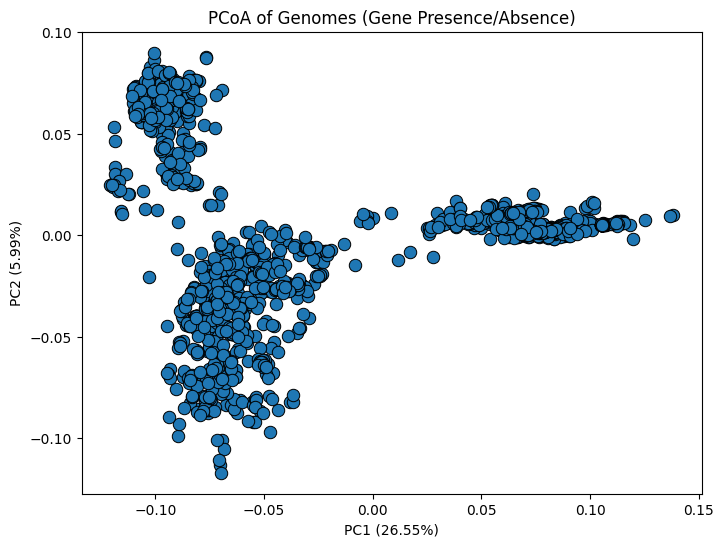

In [3]:
pa_data_rtab = pd.read_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/gene_presence_absence.Rtab",sep="\t")
genomes = pa_data_rtab.columns[1:]   # including only the genome columns

presence_absence = pa_data_rtab[genomes].astype(int).T  # genes as coulums and genomes as rows
presence_absence.index.name = "Genome"  
 
dist_matrix = pdist(presence_absence.values, metric="jaccard")  # calculating pairwise jaccard distance
dist_matrix_square = squareform(dist_matrix)  # converting to a square distance matrix

dm = DistanceMatrix(dist_matrix_square, ids=presence_absence.index) #PCoA
pcoa_result = pcoa(dm) 

coords = pcoa_result.samples[["PC1", "PC2"]].copy() # extracting PC1 and PC2 coordinates

plt.figure(figsize=(8,6))    # plot
sns.scatterplot(data=coords, x="PC1", y="PC2", s=80, edgecolor='k')
plt.title("PCoA of Genomes (Gene Presence/Absence)")
plt.xlabel(f"PC1 ({pcoa_result.proportion_explained['PC1']*100:.2f}%)")
plt.ylabel(f"PC2 ({pcoa_result.proportion_explained['PC2']*100:.2f}%)")
plt.show()

In [56]:
# three distinct clusters formed. core and soft core are nearly present in all the genomes 
# to undestand the distribution of genomic islands, amr, virulence genes and mges, accessory gene plots could provide better insights

# Accessory genes (present in < 95% of the genomes) - presence absence data

In [57]:
pa_data_acc = pa_data_rtab[~pa_data_rtab['Gene'].isin(core_genes)]
pa_data_acc.shape

(22087, 1867)

In [58]:
#pa_data_acc.to_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/1_core_removed.csv")

## PCoA - accessory genes

In [4]:
pa_data_acc = pd.read_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/1_core_removed.csv")

In [5]:
pa_data_acc.columns

Index(['Unnamed: 0', 'Gene', 'VC_0001', 'VC_0002', 'VC_0003', 'VC_0004',
       'VC_0005', 'VC_0006', 'VC_0007', 'VC_0008',
       ...
       'VC_1857', 'VC_1858', 'VC_1859', 'VC_1860', 'VC_1861', 'VC_1862',
       'VC_1863', 'VC_1864', 'VC_1865', 'VC_1866'],
      dtype='object', length=1868)

/home/dell/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


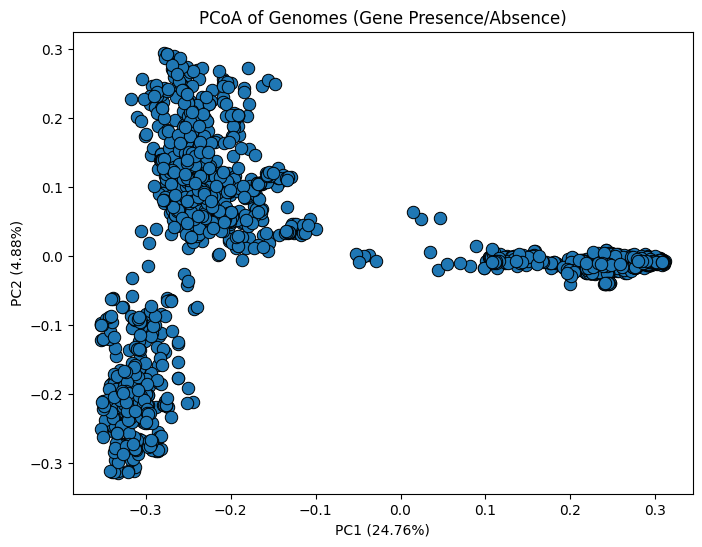

In [6]:
genomes = pa_data_acc.columns[2:]   # excluded 'Unnamed: 0' and 'Gene' columns

presence_absence = pa_data_acc[genomes].astype(int).T # genes - rows and genomes - columns
presence_absence.index.name = "Genome"

dist_matrix = pdist(presence_absence.values, metric="jaccard")  # calculating pairwise jaccard distance
dist_matrix_square = squareform(dist_matrix) # converting to a square distance matrix

dm = DistanceMatrix(dist_matrix_square, ids=presence_absence.index) #PCoA
pcoa_result = pcoa(dm)

coords = pcoa_result.samples[["PC1", "PC2"]].copy() # extracting PC1 and PC2 coordinates

plt.figure(figsize=(8,6))    # plots
sns.scatterplot(data=coords, x="PC1", y="PC2", s=80, edgecolor='k')
plt.title("PCoA of Genomes (Gene Presence/Absence)")
plt.xlabel(f"PC1 ({pcoa_result.proportion_explained['PC1']*100:.2f}%)")
plt.ylabel(f"PC2 ({pcoa_result.proportion_explained['PC2']*100:.2f}%)")
plt.show()

In [62]:
variance = pcoa_result.proportion_explained
print(variance[:50])

PC1     0.247568
PC2     0.048793
PC3     0.039483
PC4     0.026709
PC5     0.017611
PC6     0.017009
PC7     0.014876
PC8     0.013776
PC9     0.013148
PC10    0.012461
PC11    0.011994
PC12    0.010129
PC13    0.009530
PC14    0.009210
PC15    0.008885
PC16    0.008117
PC17    0.008081
PC18    0.007707
PC19    0.007315
PC20    0.006960
PC21    0.006671
PC22    0.006304
PC23    0.006199
PC24    0.005924
PC25    0.005757
PC26    0.005441
PC27    0.005318
PC28    0.005262
PC29    0.005126
PC30    0.004816
PC31    0.004745
PC32    0.004532
PC33    0.004402
PC34    0.004258
PC35    0.004087
PC36    0.004019
PC37    0.003968
PC38    0.003920
PC39    0.003833
PC40    0.003749
PC41    0.003573
PC42    0.003541
PC43    0.003473
PC44    0.003312
PC45    0.003268
PC46    0.003163
PC47    0.003084
PC48    0.003003
PC49    0.002983
PC50    0.002937
dtype: float64


In [63]:
variance[:40].sum()

np.float64(0.6376935131559243)

In [64]:
# to characterize differences in accessory genome composition among genomes, the analysis is restricted to accessory genes

### k-means clustering

In [65]:
X = coords.iloc[:, :40].values  # top 40 PCs (approximately 64% of total variance)
X = StandardScaler().fit_transform(X) # scaling

# identifying the optimal number of clusters
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=20 )
    labels = kmeans.fit_predict(X) # assigning genomes to k clusters
    
    if len(set(labels)) > 1:
        score = silhouette_score(X, labels) # evaluating cluster separation
    else:
        score = -1 # invalid clustering when only one cluster is formed
    
    sil_scores.append(score) # silhouette score for each k

k_list = list(k_range)
best_k = k_list[np.argmax(sil_scores)] # k with the highest silhoette score

print("Silhouette scores:", sil_scores)
print("Best k:", best_k)

Silhouette scores: [0.6065928825398637, 0.7803158443834411, 0.7302720502460965, 0.7139829288814159, 0.6866416276372794, 0.616021196311011, 0.6125283396381498, 0.5956331331495156]
Best k: 3


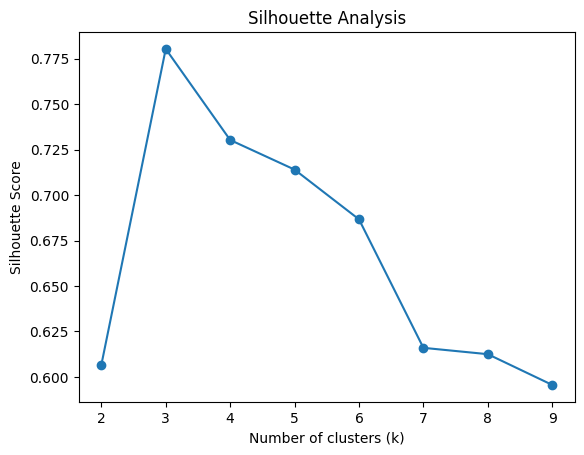

In [66]:
plt.plot(k_list, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

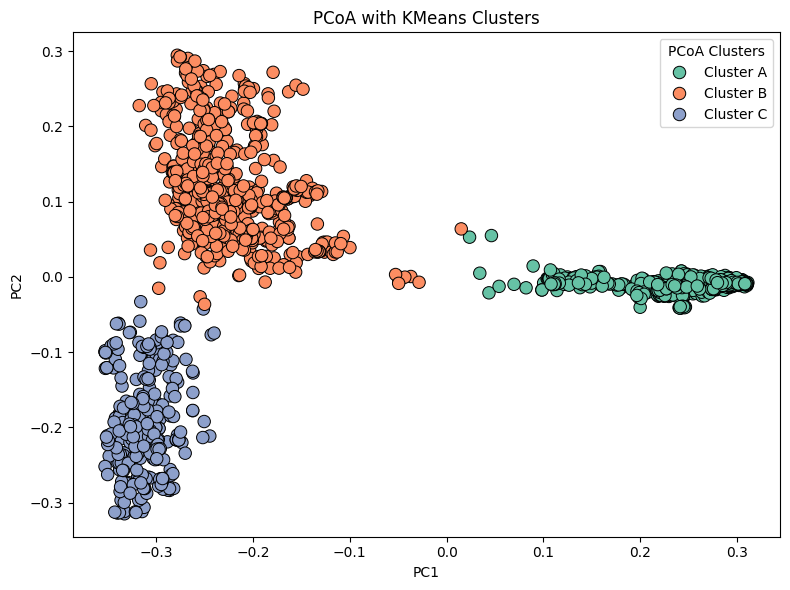

In [67]:
kmeans = KMeans(n_clusters=3, random_state=42)
coords["Cluster"] = kmeans.fit_predict(coords[["PC1", "PC2"]])
coords["Cluster"] = coords["Cluster"].map({0: "Cluster B",1: "Cluster A",2: "Cluster C"})
coords["Cluster"] = pd.Categorical(coords["Cluster"],categories=["Cluster A", "Cluster B", "Cluster C"],ordered=True)

plt.figure(figsize=(8,6))
sns.scatterplot(data=coords, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=80,  edgecolor='k')
plt.title("PCoA with KMeans Clusters")
plt.legend(title="PCoA Clusters")
plt.tight_layout()
plt.show()

## metadata merge

In [10]:
coords = coords.reset_index()
#coords.to_csv('/media/dell/My Passport/vc_files_v_final/2_population structure/pcoa_clusters.csv')
coords

,index,PC1,PC2
0,VC_0001,-0.265507,0.197515
1,VC_0002,-0.221530,0.239978
2,VC_0003,-0.187232,-0.006869
3,VC_0004,-0.179092,0.271777
4,VC_0005,0.226959,-0.010345
...,...,...,...
1861,VC_1862,0.278205,-0.004072
1862,VC_1863,0.284452,-0.008291
1863,VC_1864,0.279626,-0.007677
1864,VC_1865,0.143327,-0.009755


In [71]:
metadata = pd.read_csv("/media/dell/My Passport/vc_files_v_final/1_data_curation/metadata_filtered.csv")
metadata = metadata.drop('Unnamed: 0', axis=1)
coords = coords.rename(columns={'index': 'Sample_ID'})
coords.columns
merged = pd.merge(coords, metadata, on="Sample_ID", how='left')

In [72]:
dist_matrix

array([0.68005181, 0.8327606 , 0.72273325, ..., 0.47931873, 0.49882904,
       0.0927357 ], shape=(1740045,))

In [73]:
print(len(dist_matrix))
print(len(metadata))

1740045
1866


In [74]:
clusters = merged[['Sample_ID','PC1','PC2','Cluster']]

In [75]:
clusters

,Sample_ID,PC1,PC2,Cluster
0,VC_0001,-0.265507,0.197515,Cluster B
1,VC_0002,-0.221530,0.239978,Cluster B
2,VC_0003,-0.187232,-0.006869,Cluster B
3,VC_0004,-0.179092,0.271777,Cluster B
4,VC_0005,0.226959,-0.010345,Cluster A
...,...,...,...,...
1861,VC_1862,0.278205,-0.004072,Cluster A
1862,VC_1863,0.284452,-0.008291,Cluster A
1863,VC_1864,0.279626,-0.007677,Cluster A
1864,VC_1865,0.143327,-0.009755,Cluster A


### tree representation for clusters

In [77]:
clusters = clusters[['Sample_ID','Cluster']]
label_color_dict = {"Cluster A" : "#4E79A7","Cluster B" : "#F28E2B", "Cluster C" : "#59A14F" }

clusters_itol = clusters[['Sample_ID','Cluster']].copy()
clusters_itol["Color"] = clusters_itol["Cluster"].map(label_color_dict).astype(object).fillna("#D3D3D3")

for _, row in clusters_itol.iterrows():
    print(f"{row['Sample_ID']}\t{row['Color']}\t{row['Cluster']}")

VC_0001	#F28E2B	Cluster B
VC_0002	#F28E2B	Cluster B
VC_0003	#F28E2B	Cluster B
VC_0004	#F28E2B	Cluster B
VC_0005	#4E79A7	Cluster A
VC_0006	#F28E2B	Cluster B
VC_0007	#4E79A7	Cluster A
VC_0008	#F28E2B	Cluster B
VC_0009	#4E79A7	Cluster A
VC_0010	#F28E2B	Cluster B
VC_0011	#F28E2B	Cluster B
VC_0012	#F28E2B	Cluster B
VC_0013	#F28E2B	Cluster B
VC_0014	#4E79A7	Cluster A
VC_0015	#4E79A7	Cluster A
VC_0016	#4E79A7	Cluster A
VC_0017	#4E79A7	Cluster A
VC_0018	#F28E2B	Cluster B
VC_0019	#F28E2B	Cluster B
VC_0020	#4E79A7	Cluster A
VC_0021	#4E79A7	Cluster A
VC_0022	#4E79A7	Cluster A
VC_0023	#4E79A7	Cluster A
VC_0024	#4E79A7	Cluster A
VC_0025	#4E79A7	Cluster A
VC_0026	#4E79A7	Cluster A
VC_0027	#59A14F	Cluster C
VC_0028	#F28E2B	Cluster B
VC_0029	#4E79A7	Cluster A
VC_0030	#F28E2B	Cluster B
VC_0031	#F28E2B	Cluster B
VC_0032	#4E79A7	Cluster A
VC_0033	#4E79A7	Cluster A
VC_0034	#4E79A7	Cluster A
VC_0035	#4E79A7	Cluster A
VC_0036	#4E79A7	Cluster A
VC_0037	#4E79A7	Cluster A
VC_0038	#4E79A7	Cluster A
VC_0039	#4E7

In [78]:
# checked - consistent with the previous results 
# changes made: the renaming of clusters as A, B and C from 1,0 and 2 is done after kmeans itself

# Pandemicity and serotypes

## Mapping and core genome phylogeny

/tmp/ipykernel_4346/3583978709.py:82: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=coords[coords["serogroup_serotype"] == "Non_O1"],


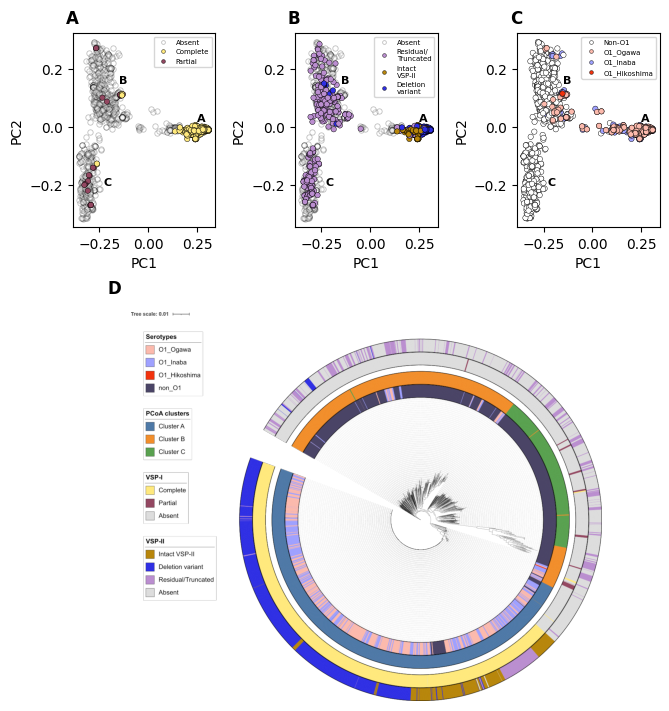

In [75]:
# creating figure layout with three PCoA panels and one phylogenetic tree panel
fig = plt.figure(figsize=(6.58, 7), constrained_layout=True)
gs = GridSpec(2, 3,figure=fig,height_ratios=[1, 2])  

# pcoa plots
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])

# phylogenetic tree
axD = fig.add_subplot(gs[1, :])

axes = [axA, axB, axC]

# VSP-I mapped onto the accessory genome PCoA
vspI = pd.read_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspI/vspI_info.csv")

vspI = vspI[['Sample_ID','vspI_status']]
vspI.rename(columns={'vspI_status': 'VSPI genomic islands'}, inplace=True)
vspI["VSPI genomic islands"] = vspI["VSPI genomic islands"].str.capitalize()


coords = pcoa_result.samples[["PC1", "PC2"]].copy()
colors = {'Absent': 'white', 'Partial': '#934761', 'Complete': '#FFE97D'}  
coords = coords.merge(vspI[["Sample_ID", "VSPI genomic islands"]],left_index=True,right_on="Sample_ID")

sns.scatterplot(data=coords[coords["VSPI genomic islands"] == "Absent"],x="PC1",y="PC2",color="white",label="Absent",edgecolor="k",s=15,alpha=0.25,
                linewidth=0.6,ax=axes[0])

sns.scatterplot(data=coords[coords["VSPI genomic islands"] != "Absent"],x="PC1",y="PC2",hue="VSPI genomic islands",palette=colors,s=15,edgecolor="k",ax=axes[0])

#legend
axes[0].legend(loc="upper right",fontsize=5,markerscale=0.7)

# panel label
axes[0].text(-0.05, 1.05,"A",transform=axes[0].transAxes,fontsize=12,fontweight="bold")

# cluster labels
axes[0].text(0.25, 0.02, "A", fontsize=8, fontweight="bold")
axes[0].text(-0.15, 0.15, "B",fontsize=8,fontweight="bold")
axes[0].text(-0.23, -0.20, "C",fontsize=8,fontweight="bold")

# VSP-II status mapped onto the accessory genome PCoA
vspII = pd.read_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/genomic_islands/vspII/vspII_info.csv")
vspII = vspII[['Sample_ID','pattern']]
vspII.rename(columns={'pattern': 'VSPII genomic islands'}, inplace=True)
#vspII["VSPII genomic islands"] = vspII["VSPII genomic islands"].str.capitalize()

coords = pcoa_result.samples[["PC1", "PC2"]].copy()
colors = {'Absent': 'white','Deletion variant': '#2F2FE4','Intact VSP-II': 'darkgoldenrod','Residual/Truncated': '#BB8ED0'}

coords = coords.merge(vspII[["Sample_ID", "VSPII genomic islands"]],left_index=True,right_on="Sample_ID")

sns.scatterplot(data=coords[coords["VSPII genomic islands"] == "Absent"],x="PC1",y="PC2",color="white",label="Absent",edgecolor="k",s=15,alpha=0.25,
                linewidth=0.6,ax=axes[1])

sns.scatterplot(data=coords[coords["VSPII genomic islands"] != "Absent"],x="PC1",y="PC2",hue="VSPII genomic islands",palette=colors,s=15,edgecolor="k",ax=axes[1])

#legend
handles, labels = axes[1].get_legend_handles_labels()
labels = [textwrap.fill(label, width=9) for label in labels]
axes[1].legend(handles, labels, loc="upper right",fontsize=5, markerscale=0.7)

# panel label
axes[1].text(-0.05, 1.05,"B",transform=axes[1].transAxes,fontsize=12,fontweight="bold")

# cluster label
axes[1].text(0.25, 0.02, "A", fontsize=8, fontweight="bold")
axes[1].text(-0.15, 0.15, "B",fontsize=8,fontweight="bold")
axes[1].text(-0.23, -0.20, "C",fontsize=8,fontweight="bold")

# serogroup_serotype distribution mapped onto the accessory genome PCoA
sero_pred = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/serotypes_predicted.csv")
sero_pred = sero_pred[['Sample_ID','all_serotypes']]
sero_pred.rename(columns={'all_serotypes': 'serogroup_serotype'}, inplace=True)
sero_pred["serogroup_serotype"] = sero_pred["serogroup_serotype"].replace("non_O1", "Non-O1")

coords = pcoa_result.samples[["PC1", "PC2"]].copy()
colors = {"Non-O1": 'white',"O1_Ogawa": '#FCBAAD',"O1_Inaba": '#9FA1FF',"O1_Hikoshima": '#F2320C'}
coords = coords.merge(sero_pred[["Sample_ID", "serogroup_serotype"]],left_index=True,right_on="Sample_ID")

sns.scatterplot(data=coords[coords["serogroup_serotype"] == "Non_O1"],
    x="PC1", y="PC2",hue="serogroup_serotype",palette=colors,s=15, alpha=0.25, edgecolor="k", linewidth=0.6,ax=axes[2])
sns.scatterplot(data=coords[(coords["serogroup_serotype"] != "Non_O1") & (coords["serogroup_serotype"] != "O1_Hikoshima")],
    x="PC1", y="PC2",hue="serogroup_serotype",palette=colors,s=15, alpha=1, edgecolor="k",ax=axes[2])
sns.scatterplot(data=coords[coords["serogroup_serotype"] == "O1_Ogawa"],x="PC1", y="PC2",hue="serogroup_serotype",
    palette=colors,s=15, alpha=1, edgecolor="k", legend = False, ax=axes[2])
sns.scatterplot(data=coords[coords["serogroup_serotype"] == "O1_Hikoshima"],x="PC1", y="PC2",hue="serogroup_serotype",
    palette=colors,s=15, alpha=1, edgecolor="k", ax=axes[2])

#legend
axes[2].legend(loc="upper right",fontsize=5,markerscale=0.7)

# panel label
axes[2].text(-0.05, 1.05,"C",transform=axes[2].transAxes,fontsize=12,fontweight="bold")

# cluster label
axes[2].text(0.25, 0.02, "A", fontsize=8, fontweight="bold")
axes[2].text(-0.15, 0.15, "B",fontsize=8,fontweight="bold")
axes[2].text(-0.23, -0.20, "C",fontsize=8,fontweight="bold")

# core genome phylogenetic tree
img = mpimg.imread("/media/dell/My Passport/vc_files_v_final/plots/core_genome_phylogeny.png")
axD.imshow(img)
axD.axis("off")

# panel label
axD.text(-0.05, 1.05,"D",transform=axD.transAxes,fontsize=12,fontweight="bold")

plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/tif_files/1_pcoa_phylogeny.tiff",
            dpi=300,bbox_inches="tight",pil_kwargs={"compression": "tiff_lzw"})

plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/pdf_files/1_pcoa_phylogeny.pdf",bbox_inches="tight")
plt.show()

## PERMANOVA

In [20]:
def run_permanova(dm, pcoa_result, data, col):

    coords = pcoa_result.samples[["PC1", "PC2"]].copy()
    coords = coords.merge(data[["Sample_ID", col]],left_index=True,right_on="Sample_ID")
    coords = coords.set_index("Sample_ID")
    coords.index = coords.index.str.strip()
    coords = coords.reindex(dm.ids)
    coords = coords.dropna(subset=[col])
    dm_subset = dm.filter(coords.index)
    
    result = permanova(dm_subset,coords[col], seed = 42)

    F = result["test statistic"]
    n = result["sample size"]
    g = result["number of groups"]
    r2 = (F * (g - 1)) / (F * (g - 1) + (n - g))

    print(f"\n{'='*60}")
    print(col)
    print(result)
    print(f"R² = {r2:.4f}")

    return result, r2

In [21]:
vspI_result, vspI_r2 = run_permanova(dm, pcoa_result,data=vspI,col="VSPI genomic islands")
vspII_result, vspII_r2 = run_permanova(dm, pcoa_result,data=vspII,col="VSPII genomic islands")
sero_result, sero_r2 = run_permanova(dm, pcoa_result,data=sero_pred,col="serogroup_serotype")


VSPI genomic islands
method name                PERMANOVA
test statistic name         pseudo-F
sample size                     1866
number of groups                   3
test statistic            275.349468
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object
R² = 0.2282

VSPII genomic islands
method name                PERMANOVA
test statistic name         pseudo-F
sample size                     1866
number of groups                   4
test statistic            166.863134
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object
R² = 0.2119

serogroup_serotype
method name                PERMANOVA
test statistic name         pseudo-F
sample size                     1866
number of groups                   4
test statistic            158.164841
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object
R² = 0.2031


In [24]:
metrics_df = pd.DataFrame({"Feature": ["VSP-I genomic islands","VSP-II genomic islands","Serotype"],
                           "Pseudo-F": [vspI_result["test statistic"],vspII_result["test statistic"],sero_result["test statistic"]],
                           "R²": [vspI_r2,vspII_r2,sero_r2],
                           "p-value": [vspI_result["p-value"],vspII_result["p-value"],sero_result["p-value"]]}).round(4)

metrics_df

,Feature,Pseudo-F,R²,p-value
0,VSP-I genomic islands,275.3495,0.2282,0.001
1,VSP-II genomic islands,166.8631,0.2119,0.001
2,Serotype,158.1648,0.2031,0.001


In [25]:
# checked - consisitent with the previous results
# VSP-I, VSP-II, and serotype were strongly associated with accessory genome variation
# continent showed a weaker association 

# Seventh Pandemic and year bins

<Axes: xlabel='PC1', ylabel='PC2'>

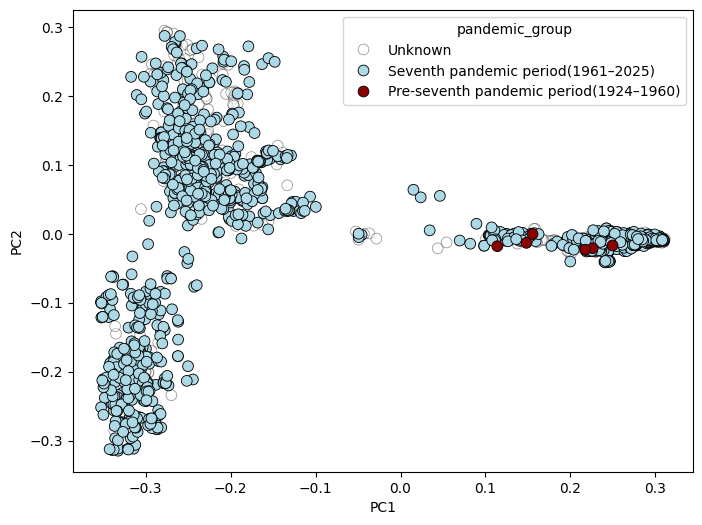

In [36]:
coords_pandemic = pcoa_result.samples[["PC1", "PC2"]].copy()

coords_pandemic = coords_pandemic.merge(metadata[["Sample_ID", "year_bin"]],left_index=True,right_on="Sample_ID")

mapping = {
    "1924–1960": "Pre-seventh pandemic period(1924–1960)",
    "1961–1972": "Seventh pandemic period(1961–2025)",
    "1973–1991": "Seventh pandemic period(1961–2025)",
    "1992–2025": "Seventh pandemic period(1961–2025)",
    "unkwn": "Unknown"
}

coords_pandemic["pandemic_group"] = coords_pandemic["year_bin"].map(mapping)

colors = {"Seventh pandemic period(1961–2025)": "lightblue",
          "Pre-seventh pandemic period(1924–1960)": "darkred",
          "Unknown": "white"}

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=coords_pandemic[coords_pandemic["pandemic_group"] == "Unknown"],
    x="PC1", y="PC2",
    hue="pandemic_group",
    palette=colors,
    edgecolor="black",
    s=60, alpha=0.4, linewidth=0.6,
)

sns.scatterplot(
    data=coords_pandemic[coords_pandemic["pandemic_group"] == "Seventh pandemic period(1961–2025)"],
    x="PC1", y="PC2",
    hue="pandemic_group",
    palette=colors,
    s=60, alpha=1, edgecolor="k",
)

sns.scatterplot(
    data=coords_pandemic[coords_pandemic["pandemic_group"] == "Pre-seventh pandemic period(1924–1960)"],
    x="PC1", y="PC2",
    hue="pandemic_group",
    palette=colors,
    s=60, alpha=1, edgecolor="k"
)

In [38]:
coords_pandemic_perm = coords_pandemic.copy()
coords_pandemic_perm = coords_pandemic_perm.set_index("Sample_ID") # sampleid as index
coords_pandemic_perm = coords_pandemic_perm[coords_pandemic_perm["pandemic_group"] != "Unknown"] # removing genomes with unknown year bins 

dm_pandemic = dm.filter(coords_pandemic_perm.index)
#testing whether the distances between groups are significantly greater than the distances within groups
result_pandemic = permanova(dm_pandemic,coords_pandemic_perm["pandemic_group"])  # fixed the random seed for reproducibility
print(result_pandemic)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1522
number of groups                  2
test statistic             2.240389
p-value                       0.029
number of permutations          999
Name: PERMANOVA results, dtype: object


In [39]:
F = result_pandemic["test statistic"]
n = result_pandemic["sample size"]
g = result_pandemic["number of groups"]
r2 = (F * (g - 1)) / (F * (g - 1) + (n - g))    
# F = (variation wbetween the groups / (num_groups - 1))/(variation witin the group/(sample_size - num_groups)
# R^2 = variation between the groups/(variation wbetween the groups + variation within the groups) 

print(f'R^2 =', r2)

R^2 = 0.0014717707982017684


In [41]:
# significant differences between seventh and pre-seventh pandemic genomes were identified (p < 0.05)
# all 8/1866 pre-seventh pandemic genomes were grouped within a single cluster in the accessory gene PCoA

# continent wise

In [44]:
continent_map = {
    "Bangladesh": "Asia","China": "Asia","Viet nam": "Asia","India": "Asia","Japan": "Asia",
    "South korea": "Asia","Thailand": "Asia","Philippines": "Asia","Indonesia": "Asia",
    "Malaysia": "Asia","Pakistan": "Asia","Iraq": "Asia","Azerbaijan": "Asia","Qatar": "Asia",
    "Yemen": "Asia","Lebanon": "Asia","Bahrain": "Asia","Myanmar": "Asia","Cambodia": "Asia",
    "Hong kong": "Asia",

    "Russia": "Europe","Germany": "Europe","Austria": "Europe","Switzerland": "Europe",
    "Spain": "Europe","Ukraine": "Europe","Sweden": "Europe","Ireland": "Europe",
    "Hungary": "Europe","Norway": "Europe","Slovakia": "Europe","United kingdom": "Europe",
    "Czechoslovakia": "Europe",

    "Mozambique": "Africa","Tanzania": "Africa","Kenya": "Africa","Cameroon": "Africa",
    "Nigeria": "Africa","Democratic republic of the congo": "Africa","Ghana": "Africa",
    "Uganda": "Africa","Sudan": "Africa","Zambia": "Africa","South africa": "Africa",
    "Egypt": "Africa","Algeria": "Africa","Angola": "Africa","Guinea": "Africa",
    "Zimbabwe": "Africa","Comoros": "Africa","Morocco": "Africa","Senegal": "Africa",
    "Mayotte": "Africa","Ethiopia": "Africa","Sierra leone": "Africa","Chad": "Africa",
    "Ussr": "Africa", 

    "Usa": "North America","Haiti": "North America","Mexico": "North America",
    "Canada": "North America","Dominican republic": "North America",

    "Brazil": "South America","Peru": "South America","Argentina": "South America",
    "Chile": "South America","Colombia": "South America",

    "Australia": "Oceania","Guam": "Oceania"
}

metadata["Continent"] = metadata["Assembly BioSample Geographic location"].map(continent_map).fillna("Unknown")

others_list = [
    "Ukwn","Ussr","Czechoslovakia","United kingdom","Dominican republic","Mayotte",
    "Comoros","Guinea","Zimbabwe","Slovakia","Senegal","Myanmar","Ethiopia","Cambodia",
    "Sierra leone","Hong kong","Chad","Norway","Angola","Colombia","Chile","Argentina",
    "Azerbaijan","Iraq","Qatar","Yemen","Lebanon","Guam","Bahrain","Hungary","Algeria",
    "Egypt","Sweden","Ireland","Pakistan","Malaysia","Indonesia","Philippines","Thailand",
    "Sudan","Zambia","Peru","South korea","Ghana","Uganda","Ukwn","Haiti","Austria",
    "Tanzania","Cameroon","Switzerland","Spain","Germany",
    "Australia", "Canada", "South africa", "Morocco", "Viet nam"
]

metadata["Group"] = metadata["Assembly BioSample Geographic location"].replace(others_list, "Others")

metadata[["Group","Assembly BioSample Geographic location",'Continent']]

,Group,Assembly BioSample Geographic location,Continent
0,India,India,Asia
1,India,India,Asia
2,India,India,Asia
3,Others,Philippines,Asia
4,India,India,Asia
...,...,...,...
1861,Bangladesh,Bangladesh,Asia
1862,Bangladesh,Bangladesh,Asia
1863,Bangladesh,Bangladesh,Asia
1864,Others,Czechoslovakia,Europe


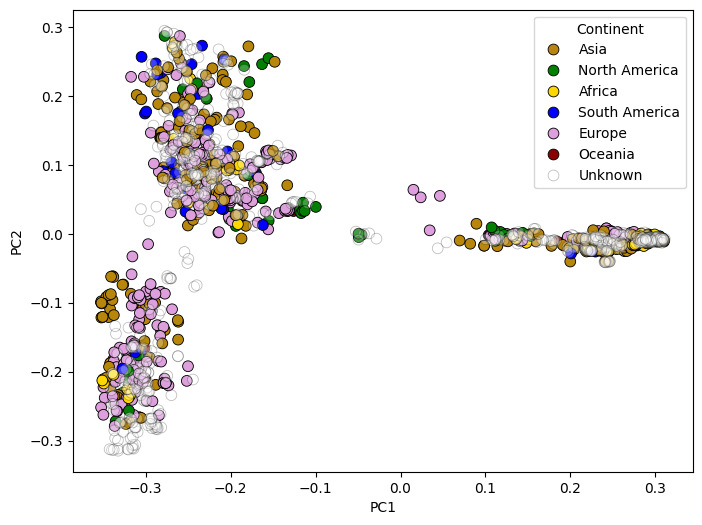

In [45]:
coords_continent = pcoa_result.samples[["PC1", "PC2"]].copy()

continent_colors = {
    'Asia': 'darkgoldenrod',
    'Europe': 'plum',
    'North America': 'green',
    'Africa': 'gold',
    'South America': 'blue',
    'Oceania': 'darkred',
    'Unknown': 'white'
}

coords_continent = coords_continent.merge(metadata[["Sample_ID", "Continent"]],left_index=True,right_on="Sample_ID")

plt.figure(figsize=(8,6))

sns.scatterplot(data=coords_continent[(coords_continent["Continent"] != "Unknown")],
                x="PC1", y="PC2",hue="Continent",palette=continent_colors,s=60,alpha=1,edgecolor="k")

sns.scatterplot(data=coords_continent[coords_continent["Continent"] == "Unknown"],
                x="PC1", y="PC2",hue="Continent",palette=continent_colors,edgecolor="black",s=60,alpha=0.25,linewidth=0.6)

plt.show()

In [46]:
coords_continent_perm = coords_continent.copy()

coords_continent_perm = coords_continent_perm[coords_continent_perm["Continent"] != "Unknown"].copy()

coords_continent_perm = coords_continent_perm.set_index("Sample_ID")

dm_continent = dm.filter(coords_continent_perm.index)

result_continent = permanova(dm_continent,coords_continent_perm["Continent"])

print(result_continent)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1267
number of groups                  6
test statistic            28.941018
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


# Misclassified genomes

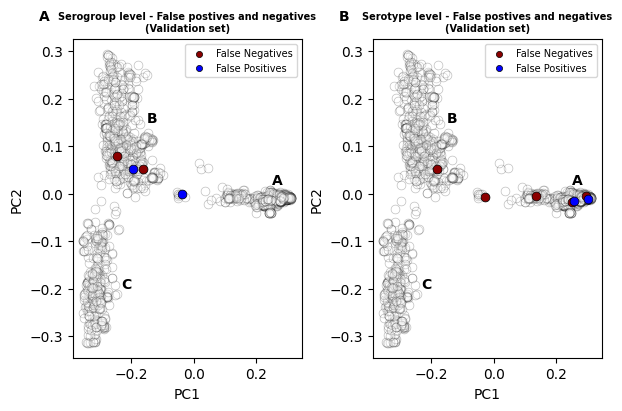

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(6,4), constrained_layout=True)

# Panel A for Serogroup
fn_ids_sg = ['VC_1642', 'VC_0031']
fp_ids_sg = ['VC_1084', 'VC_1081']

sns.scatterplot(data=coords, x="PC1", y="PC2",color="white", edgecolor="k",s=40, alpha=0.25, ax=axes[0])

sns.scatterplot(data=coords[coords["Sample_ID"].isin(fn_ids_sg)],x="PC1", y="PC2",color="darkred", 
                edgecolor="black",s=40, label="False Negatives",ax=axes[0])

sns.scatterplot(data=coords[coords["Sample_ID"].isin(fp_ids_sg)],x="PC1", y="PC2",color="blue",
                edgecolor="black",s=40, label="False Positives",ax=axes[0])

#legend
axes[0].legend(loc="upper right",fontsize=7,markerscale=0.7)

axes[0].set_title("Serogroup level - False postives and negatives\n(Validation set)", fontweight="bold",fontsize=7)
axes[0].text(-0.15, 1.06, "A",transform=axes[0].transAxes,fontsize=10, fontweight="bold")
axes[0].text(0.25, 0.02, "A", fontsize=10, fontweight="bold")
axes[0].text(-0.15, 0.15, "B",fontsize=10,fontweight="bold")
axes[0].text(-0.23, -0.20, "C",fontsize=10,fontweight="bold")

# Panel B for Serotype
fn_ids = ['VC_1675', 'VC_0007', 'VC_1628', 'VC_0092', 'VC_1525']
fp_ids = ['VC_0098', 'VC_0065']

sns.scatterplot(data=coords, x="PC1", y="PC2",color="white", edgecolor="k",s=40, alpha=0.25, ax=axes[1])

sns.scatterplot(data=coords[coords["Sample_ID"].isin(fn_ids)],x="PC1", y="PC2",color="darkred", 
                edgecolor="black",s=40, label="False Negatives",ax=axes[1])

sns.scatterplot(data=coords[coords["Sample_ID"].isin(fp_ids)],x="PC1", y="PC2",color="blue", edgecolor="black",
                s=40, label="False Positives",ax=axes[1])

axes[1].legend(loc="upper right",fontsize=7,markerscale=0.7)
axes[1].set_title("Serotype level - False postives and negatives\n(Validation set)", fontweight="bold",fontsize=7)
axes[1].text(-0.15, 1.06, "B",transform=axes[1].transAxes,fontsize=10, fontweight="bold")
axes[1].text(0.25, 0.02, "A", fontsize=10, fontweight="bold")
axes[1].text(-0.15, 0.15, "B",fontsize=10,fontweight="bold")
axes[1].text(-0.23, -0.20, "C",fontsize=10,fontweight="bold")

plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/pdf_files/1_sup_misclassified_genomes.pdf",bbox_inches="tight")
plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/tif_files/1_sup_misclassified_genomes.tiff",dpi=300,bbox_inches="tight",pil_kwargs={"compression": "tiff_lzw"})
plt.show()

In [34]:
# checked - consistent with the previous results